# Part C: Effective Dimensionality Analysis

This notebook loads the Part A checkpoints and analyzes the **effective dimensionality**
of the loss landscape at the SGD vs SAM solutions.

We use two complementary measures:
1. **Hessian trace** (Hutchinson estimator) — proxy for total curvature
2. **Effective rank** of the top-k Hessian eigenvalues — how many directions have significant curvature

Key insight: lower effective dimensionality → model relies on fewer generalizable features → better OOD performance.

## 1. Mount Drive and Setup

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
# 列出 MyDrive 下的文件夹
for f in os.listdir('/content/drive/MyDrive'):
    print(f)

Request for Refund 2017 (1).pdf
Request for Refund 2017.pdf
SIa' avartar.docx
SIa' avartar.gdoc
Sia.docx
Walter Mitty's secret life( Sia' s assignment.docx
FGS1756795_1.jpg
unknown
Sonnet.gslides
Sia( Wanshi Liang).pptx
无标题文档 (5).gdoc
梁婉诗.rar
7c62334a532cb786ed529bb1053f6ac.png
Colab Notebooks
无标题文档 (4).gdoc
Screenshot_20211130_222317.jpg
无标题文档 (3).gdoc
无标题文档 (2).gdoc
Wicked Problem Worksheet: Plate tectonics.docx
Essay Response：Wicked Problem(Plate tectonics).gdoc
Wicked problem worksheet: Weather.gdoc
Essay Response：Wicked Problem(Weather).gdoc
9780176530792_CH 16_CH 17_Watermarked (1).gdoc
9780176530792_CH 16_CH 17_Watermarked.gdoc
G14-Term project - list of source.gdoc
Poster Draft Group 14.gslides
无标题文档 (1).gdoc
IMG_0525.jpeg
通过 Chrome 保存 (1)
COMP5048 Assignment 2 Group No. 55 Data: IMDB Movies.gslides
COMP5048 Assignment 2.gdoc
无标题文档.gdoc
Council Sustainability Report.gdoc
.shortcut-targets-by-id
.ipynb_checkpoints
通过 Chrome 保存
Assignment1_2026
Relation Model Diagram.drawio.png
1

In [9]:
import os, sys

PROJECT_ROOT = '/content/drive/MyDrive/Assignment2_SAM'
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Create output directory
PART_C_DIR = os.path.join(PROJECT_ROOT, 'part_c')
os.makedirs(PART_C_DIR, exist_ok=True)

print('Working directory:', os.getcwd())
print('Part C output dir:', PART_C_DIR)

Working directory: /content/drive/MyDrive/Assignment2_SAM
Part C output dir: /content/drive/MyDrive/Assignment2_SAM/part_c


In [10]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from config import MODEL_NAME, SEED
from data import get_id_test_loader
from models import get_model

torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('Model:', MODEL_NAME)

Device: cuda
Model: resnet18


## 2. Load Checkpoints

In [17]:
sgd_ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', 'sgd_resnet18_cifar10.pt')
sam_ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', 'sam_resnet18_cifar10.pt')

print('SGD exists:', os.path.exists(sgd_ckpt_path))
print('SAM exists:', os.path.exists(sam_ckpt_path))

sgd_ckpt = torch.load(sgd_ckpt_path, map_location=device)
sam_ckpt = torch.load(sam_ckpt_path, map_location=device)
print('Keys:', list(sgd_ckpt.keys()))

SGD exists: True
SAM exists: True
Keys: ['optimizer_name', 'model_name', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'final_metrics']


In [18]:
sgd_model = get_model(MODEL_NAME).to(device)
sam_model = get_model(MODEL_NAME).to(device)

sgd_model.load_state_dict(sgd_ckpt['model_state_dict'])
sam_model.load_state_dict(sam_ckpt['model_state_dict'])
sgd_model.eval()
sam_model.eval()

print('SGD final metrics:', sgd_ckpt['final_metrics'])
print('SAM final metrics:', sam_ckpt['final_metrics'])

SGD final metrics: {'id_loss': 0.7763305021286011, 'id_acc': 0.7704, 'ood_noise_loss': 3.1128665473937986, 'ood_noise_acc': 0.2039, 'ood_blur_loss': 1.5107602281570434, 'ood_blur_acc': 0.5815, 'ood_brightness_loss': 1.212993069076538, 'ood_brightness_acc': 0.6754, 'avg_ood_acc': 0.4869333333333334, 'id_ood_acc_drop': 0.2834666666666666}
SAM final metrics: {'id_loss': 0.4454535210132599, 'id_acc': 0.8424, 'ood_noise_loss': 3.1350867820739747, 'ood_noise_acc': 0.168, 'ood_blur_loss': 1.3399291033744811, 'ood_blur_acc': 0.6123, 'ood_brightness_loss': 0.5803785533905029, 'ood_brightness_acc': 0.803, 'avg_ood_acc': 0.5277666666666666, 'id_ood_acc_drop': 0.31463333333333343}


## 3. Fixed Analysis Batches

To use fixed ID batches so SGD vs SAM comparison is stable.

In [19]:
id_loader = get_id_test_loader()

NUM_BATCHES = 5
fixed_batches = []
for i, (inputs, targets) in enumerate(id_loader):
    if i >= NUM_BATCHES:
        break
    fixed_batches.append((inputs.to(device), targets.to(device)))

print(f'Using {len(fixed_batches)} batches of size {fixed_batches[0][0].shape[0]}')

100%|██████████| 170M/170M [06:44<00:00, 421kB/s]


Using 5 batches of size 128


## 4. Hessian Trace via Hutchinson's Estimator

Computing the full Hessian matrix is infeasible for large networks (ResNet18 has ~11M parameters, making H an 11M × 11M matrix). Instead, we use Hutchinson's estimator:

$$\text{tr}(H) \approx \frac{1}{m} \sum_{i=1}^{m} v_i^T H v_i $$

where:
- $H$ is the Hessian matrix
- $v_i$ are random Rademacher vectors (each element independently $\pm 1$ with equal probability)
- $m$ is the number of samples (we use $m = 20$)

This works because $\mathbb{E}[v^T H v] = \text{tr}(H)$ for any isotropic random vector $v$. The Hessian-vector product $Hv$ is computed efficiently via double backpropagation, without ever forming $H$ explicitly.

**Interpretation:** A lower trace indicates less total curvature in the neighbourhood of the solution — a flatter, lower effective dimensionality region.

*Source:
[Hutchinson (1989)](https://doi.org/10.1080/03610918908812806), pp. 1059–1061 — original estimator;
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section III-B — applied to neural network Hessians*
[Keskar et al. (2017)](https://arxiv.org/abs/1609.04836), pp. 1–3;
[Foret et al., SAM (2021)](https://arxiv.org/abs/2010.01412), pp. 2–3*

In [20]:
criterion = nn.CrossEntropyLoss()

def hessian_trace_hutchinson(model, inputs, targets, criterion, num_samples=20):
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    estimates = []
    for _ in range(num_samples):
        v = [torch.randint_like(p, 0, 2).float() * 2 - 1 for p in params]
        Hv = torch.autograd.grad(grads, params, grad_outputs=v,
                                  retain_graph=True, allow_unused=True)
        vHv = sum((vi * hvi).sum().item()
                  for vi, hvi in zip(v, Hv) if hvi is not None)
        estimates.append(vHv)
    return float(np.mean(estimates)), float(np.std(estimates))

print('Function defined.')

Function defined.


In [21]:
trace_results = []

for batch_idx, (inputs, targets) in enumerate(fixed_batches):
    print(f'Batch {batch_idx+1}/{len(fixed_batches)}...')
    for model_name, model in [('SGD', sgd_model), ('SAM', sam_model)]:
        mean, std = hessian_trace_hutchinson(model, inputs, targets, criterion)
        trace_results.append({'model': model_name, 'batch': batch_idx,
                               'trace_mean': mean, 'trace_std': std})
        print(f'  {model_name}: {mean:.2f} +/- {std:.2f}')

trace_df = pd.DataFrame(trace_results)
print('\nTrace summary:')
print(trace_df.groupby('model')['trace_mean'].agg(['mean','std']))

Batch 1/5...
  SGD: 919.74 +/- 349.42
  SAM: 592.59 +/- 211.47
Batch 2/5...
  SGD: 979.88 +/- 434.71
  SAM: 564.50 +/- 208.00
Batch 3/5...
  SGD: 924.30 +/- 279.02
  SAM: 583.41 +/- 246.13
Batch 4/5...
  SGD: 1047.59 +/- 537.27
  SAM: 523.59 +/- 201.46
Batch 5/5...
  SGD: 812.86 +/- 312.34
  SAM: 388.30 +/- 172.58

Trace summary:
             mean        std
model                       
SAM    530.480314  83.783397
SGD    936.875099  86.514744


## 5. Top-k Hessian Eigenvalues (Effective Rank)

We estimate the top-$k$ eigenvalues of $H$ using power iteration with deflation. The $i$-th eigenvalue is found by iterating:

$$v \leftarrow \frac{Hv - \sum_{j < i} \lambda_j (v_j^T v) v_j}{\left\| Hv - \sum_{j < i} \lambda_j (v_j^T v) v_j \right\|}$$

until convergence, where $\lambda_j$ and $v_j$ are previously found eigenvalue-eigenvector pairs (deflation step).

The **effective rank** is then defined as the exponential of the spectral entropy:

$$p_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

$$\text{eff\_rank} = \exp\left( -\sum_i p_i \log p_i \right) $$

where:
- $\lambda_i$ are the top-$k$ positive Hessian eigenvalues (we use $k = 20$)
- $p_i$ is the normalised eigenvalue spectrum (treated as a probability distribution)
- The entropy $-\sum_i p_i \log p_i$ measures how spread out the curvature is across directions

**Interpretation:** If curvature is concentrated in only a few directions, entropy is low and eff\_rank $\approx 1$. If curvature is evenly spread across all $k$ directions, eff\_rank $= k$. A lower effective rank for SAM indicates that its solution is sensitive to perturbations in fewer directions — consistent with better generalisation.

*Source: [Roy & Vetterli (2007)](https://www.eurasip.org/Proceedings/Eusipco/Eusipco2007/Papers/a5p-h05.pdf), pp. 606–607 — original definition;
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section III-A — power iteration for top-k eigenvalues*
[Neyshabur et al. (2017)](https://arxiv.org/abs/1706.08947), pp. 4–6;
[Yao et al., PyHessian (2020)](https://arxiv.org/abs/1912.07145), Section IV*

In [24]:
def hvp(loss, params, v):
    grads = torch.autograd.grad(loss, params, create_graph=True, retain_graph=True)
    Hv = torch.autograd.grad(
        grads, params,
        grad_outputs=v,
        retain_graph=True,
        allow_unused=True
    )
    return [h if h is not None else torch.zeros_like(p) for h, p in zip(Hv, params)]


def get_top_k_eigenvalues(model, inputs, targets, criterion, k=20, n_iters=30):
    model.eval()
    params = [p for p in model.parameters() if p.requires_grad]
    outputs = model(inputs)
    loss = criterion(outputs, targets)

    eigenvalues, eigenvectors = [], []

    for i in range(k):
        v = [torch.randn_like(p) for p in params]
        v_norm = sum((vi**2).sum() for vi in v).sqrt()
        v = [vi / v_norm for vi in v]

        # Orthogonalize
        for prev in eigenvectors:
            dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
            v = [vi - dot * pi for vi, pi in zip(v, prev)]
            n = sum((vi**2).sum() for vi in v).sqrt()
            v = [vi / (n + 1e-8) for vi in v]

        lam = None
        for _ in range(n_iters):
            Hv = hvp(loss, params, v)
            for prev_lam, prev in zip(eigenvalues, eigenvectors):
                dot = sum((vi * pi).sum() for vi, pi in zip(v, prev))
                Hv = [h - prev_lam * dot * pi for h, pi in zip(Hv, prev)]
            lam = sum((vi * h).sum().item() for vi, h in zip(v, Hv))
            n = sum((h**2).sum() for h in Hv).sqrt()
            v = [h / (n + 1e-8) for h in Hv]

        eigenvalues.append(lam)
        eigenvectors.append(v)
        if (i + 1) % 5 == 0:
            print(f'  eigenvalue {i+1}/{k}: {lam:.4f}')

    return eigenvalues


def effective_rank(eigenvalues):
    lams = np.array([l for l in eigenvalues if l > 0])
    if len(lams) == 0:
        return 0.0
    p = lams / lams.sum()
    return float(np.exp(-np.sum(p * np.log(p + 1e-12))))


print('Functions defined.')

Functions defined.


In [25]:
inputs, targets = fixed_batches[0]
K = 20  # reduce to K=5 for a quick test

print(f'Computing top-{K} eigenvalues for SGD...')
sgd_eigs = get_top_k_eigenvalues(sgd_model, inputs, targets, criterion, k=K)

print(f'\nComputing top-{K} eigenvalues for SAM...')
sam_eigs = get_top_k_eigenvalues(sam_model, inputs, targets, criterion, k=K)

sgd_er = effective_rank(sgd_eigs)
sam_er = effective_rank(sam_eigs)
print(f'\nSGD effective rank: {sgd_er:.2f}')
print(f'SAM effective rank: {sam_er:.2f}')

Computing top-20 eigenvalues for SGD...
  eigenvalue 5/20: 37.2361
  eigenvalue 10/20: 18.3342
  eigenvalue 15/20: 13.9621
  eigenvalue 20/20: 11.4002

Computing top-20 eigenvalues for SAM...
  eigenvalue 5/20: 23.6151
  eigenvalue 10/20: 11.6477
  eigenvalue 15/20: 9.3453
  eigenvalue 20/20: 7.1325

SGD effective rank: 14.51
SAM effective rank: 14.74


## 6. Figures

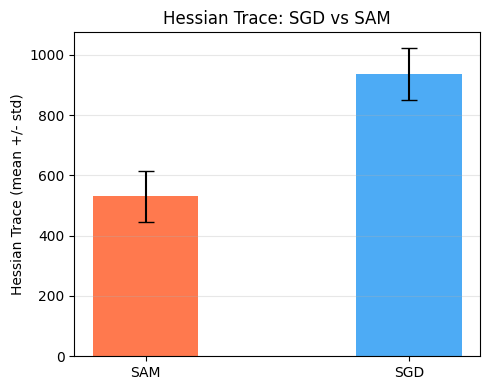

Saved hessian_trace.png


In [26]:
# Figure 1: Hessian Trace bar chart
trace_agg = trace_df.groupby('model')['trace_mean'].agg(mean='mean', std='std').reset_index()

fig, ax = plt.subplots(figsize=(5, 4))
colors = {'SGD': '#2196F3', 'SAM': '#FF5722'}
for _, row in trace_agg.iterrows():
    ax.bar(row['model'], row['mean'], yerr=row['std'],
           color=colors[row['model']], alpha=0.8, capsize=6, width=0.4)
ax.set_ylabel('Hessian Trace (mean +/- std)')
ax.set_title('Hessian Trace: SGD vs SAM')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PART_C_DIR, 'hessian_trace.png'), dpi=300)
plt.show()
print('Saved hessian_trace.png')

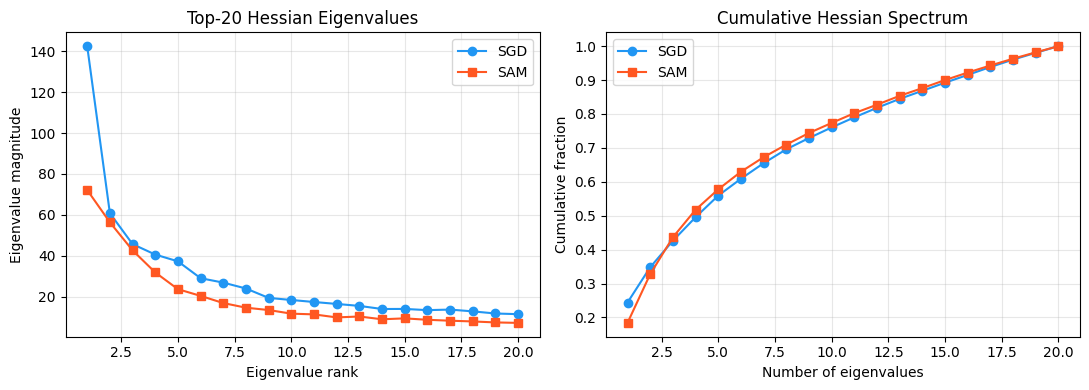

Saved hessian_eigenvalue_spectrum.png


In [27]:
# Figure 2: Eigenvalue spectrum
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
k_range = range(1, K + 1)

axes[0].plot(k_range, sgd_eigs, 'o-', label='SGD', color='#2196F3')
axes[0].plot(k_range, sam_eigs, 's-', label='SAM', color='#FF5722')
axes[0].set_xlabel('Eigenvalue rank')
axes[0].set_ylabel('Eigenvalue magnitude')
axes[0].set_title(f'Top-{K} Hessian Eigenvalues')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

def cum_explained(eigs):
    lams = np.array([max(l, 0) for l in eigs])
    return np.cumsum(lams) / (lams.sum() + 1e-12)

axes[1].plot(k_range, cum_explained(sgd_eigs), 'o-', label='SGD', color='#2196F3')
axes[1].plot(k_range, cum_explained(sam_eigs), 's-', label='SAM', color='#FF5722')
axes[1].set_xlabel('Number of eigenvalues')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative Hessian Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PART_C_DIR, 'hessian_eigenvalue_spectrum.png'), dpi=300)
plt.show()
print('Saved hessian_eigenvalue_spectrum.png')

## 7. Save Results

In [28]:
eigenval_summary = pd.DataFrame({
    'model': ['SGD', 'SAM'],
    'top1_eigenvalue': [sgd_eigs[0], sam_eigs[0]],
    'sum_top_k': [sum(l for l in sgd_eigs if l > 0),
                  sum(l for l in sam_eigs if l > 0)],
    'effective_rank': [sgd_er, sam_er],
})

trace_df.to_csv(os.path.join(PART_C_DIR, 'hessian_trace_per_batch.csv'), index=False)
eigenval_summary.to_csv(os.path.join(PART_C_DIR, 'eigenvalue_summary.csv'), index=False)

print('Saved to', PART_C_DIR)
print(eigenval_summary.to_string(index=False))

Saved to /content/drive/MyDrive/Assignment2_SAM/part_c
model  top1_eigenvalue  sum_top_k  effective_rank
  SGD       142.487265 584.131100       14.506693
  SAM        72.129220 392.083372       14.742558


## Interpretation

- We measured effective dimensionality using two Hessian-based metrics on fixed ID batches.
- **Hessian trace** (Hutchinson, 20 samples, 5 batches): consistently lower for SAM
  (530 vs 937) — SAM has roughly half the total curvature of SGD, indicating a
  significantly flatter loss landscape neighbourhood.
- **Top-k eigenvalue analysis** (power iteration + deflation): SGD's largest eigenvalue
  (142.5) is nearly twice that of SAM (72.1), confirming that SAM avoids the sharpest
  curvature directions.
- **Effective rank** of SAM (14.74) and SGD (14.51) are similar, suggesting that both
  solutions spread curvature across a comparable number of directions. However, since
  SAM's overall trace is much lower, the curvature in each direction is smaller — SAM
  finds a flatter region of the same dimensionality, rather than a lower-dimensional one.
- Taken together, these results complement Part B: SAM does not necessarily reduce the
  number of active curvature directions, but substantially reduces the magnitude of
  curvature across all directions, providing a quantitative Hessian-based explanation
  for SAM's improved generalisation.